<a href="https://colab.research.google.com/github/tuankhoin/CO3057-Computer-Vision/blob/main/Week_9_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ho Chi Minh University of Technology (HCMUT)

CO3057 - Digital Image Processing and Computer Vision

# Week 9 - Deep Learning Fundamentals

<img src="https://media.licdn.com/dms/image/v2/D4D22AQFx1oXDzInrhw/feedshare-shrink_800/feedshare-shrink_800/0/1694598504063?e=2147483647&v=beta&t=M2tNfPH_PoEK4R3qUOoUHiyBAq6bnwbeomEJYuaHrHY" height=500/>

---



---
# 1. Motivation
---

The purpose: gradually transforming raw pixels into meaningful features to do desired task.

![](https://www.ibm.com/content/adobe-cms/us/en/think/topics/image-classification/jcr:content/root/table_of_contents/body-article-8/image.coreimg.png/1763388570856/image-classification-1.png)

Vision tasks (e.g. object recognition) usually look like this:

$$
x \in \mathbb{R}^{H \times W \times C}
\xrightarrow[]{\text{A bunch of layers}} y \in \mathbb{R}^{K}
$$

> where $K$ is the number of classes.

In details, it is:

$$
x \rightarrow f_1 \rightarrow f_2 \rightarrow \cdots \rightarrow y
$$

> Each layer transforms the representation.

Today's goal is to understand **what layers can produce these transformations**.




---
# 2. Typical CNN Architecture
---

| Stage          | Purpose                      | Typical Layers Used                          |
|---------------|-----------------------------|----------------------------------------------|
| Early layers   | detect edges, textures       | Conv (small kernels 3×3), ReLU               |
| Middle layers  | detect shapes, parts         | Conv (deeper channels), ReLU, Pooling        |
| Final layers   | make decisions               | Flatten, Fully Connected (FC), Softmax       |


Example:
$$
\text{Image}
\rightarrow \text{Conv}
\rightarrow \text{Activation}
\rightarrow \text{Pooling}
\rightarrow \text{Conv}
\rightarrow \text{Flatten}
\rightarrow \text{FC}
\rightarrow \text{Output}
$$


---



# 3. Convolution Layer
---

![](https://upload.wikimedia.org/wikipedia/commons/9/90/CNN-filter-animation-1.gif)

Extracts **local features** using filters:
* edges
* corners
* textures

## 3.1 Why convolution?

Images have **spatial structure**:

* nearby pixels are related
* patterns repeat across image

## 3.2 Parameters

Parameters: kernel weights

Hyperparameters:
- $K_w \times K_h$: Filter size
- $C_{out}$: Number of filters
- $S$: stride  
- $P$: padding  

## 3.3 Output Size
Remember: an image is in the from of (width, height, color channels).

$$
{H \times W \times C}
\xrightarrow[]{conv(K_w \times K_h, C_{out})} {H_{out} \times W_{out} \times C_{out}}
$$

where:
$$
H_{out} = \frac{H - K_h + 2P}{S} + 1
$$

$$
W_{out} = \frac{W - K_w + 2P}{S} + 1
$$

> 1 is the 'bias term'

## 3.4 Parameters

The formula to calculate the number of parameters at a given Convolution layer:
$$
K \times K \times C_{in} \times C_{out}
$$

## 3.5 Signal Processing View

* Convolution = filtering
* Filters ≈ learned frequency detectors



---
# 4. Pooling Layer
---

![](https://media.geeksforgeeks.org/wp-content/uploads/20190721025744/Screenshot-2019-07-21-at-2.57.13-AM.png)

Reduces spatial resolution:

$$
H \times W \rightarrow \frac{H}{S} \times \frac{W}{S}
$$

* reduces computation
* increases robustness to small shifts
* keeps important features

Common types:
- Average Pooling → smooths signal (**low-pass filter**)
- Max Pooling → keeps strongest response (**edge-like / high-pass behavior**)

## 4.1 Output size & Parameters

Same as Convolution, except that:
- $P = 0$ (most of the time)
- $C_{in} = C_{out}$

Pooling has **no parameters/weights**, only stride and sizing hyperparameters.




---

# 5. Fully Connected (FC) Layer
---

![](https://builtin.com/sites/www.builtin.com/files/styles/ckeditor_optimize/public/inline-images/3_fully-connected-layer_0.jpg)

Combines all features globally:

$$
y_A = \Sigma_{i \in [1,9]} [w_{Ai} * x_1]
$$

## 5.1 Motivation
* convolution learns **features**
* FC makes **decisions**

⟶ maps features → class scores

## 5.2 Parameters/No. of Weights

$$
N_{in} \times N_{out}
$$

(very large → expensive computation)


---
# 6. Flatten Layer
---

![](https://www.superdatascience.com/wp-content/uploads/73_blog_image_1.png)

Convert nD to 1D:

$$
H \times W \times C \rightarrow (HWC)
$$

Motivation: Fully connected layers expect **vectors**, not images.



---
# 7. Dropout (Regularization)
---

![](https://images.viblo.asia/363449ef-bc8e-4476-98b9-a450498aa5f6.jpeg)

Randomly disables neurons:

$$
x_i = 0 \text{ with probability } p
$$

## Why?

* prevents overfitting
* forces redundancy in features



---
# 8. Summary of Common Layers (CNN)
---

| Layer | Input Size | Output Size | Parameters | Hyperparameters |
|------|-----------|------------|-----------|----------------|
| Convolution (Conv2D) | $H \times W \times C_{in}$ | $H_{out} \times W_{out} \times C_{out}$ | $K_w \times K_h \times C_{in} \times C_{out}$ | Kernel size $(K_w, K_h)$, Stride $S$, Padding $P$, Filters $C_{out}$ |
| Pooling (Max / Avg) | $H \times W \times C$ | $H_{out} \times W_{out} \times C$ | $0$ | Kernel size $K$, Stride $S$ |
| Activation (ReLU) | any | same as input | $0$ | none |
| Flatten | $H \times W \times C$ | $(HWC) \times 1$ | $0$ | none |
| Fully Connected (FC) | $N \times 1$ | $M \times 1$ | $N \times M$ | Output size $M$ |
| Dropout | any | same as input | $0$ | Drop probability $p$ |


---
# 9. Activation Function
---

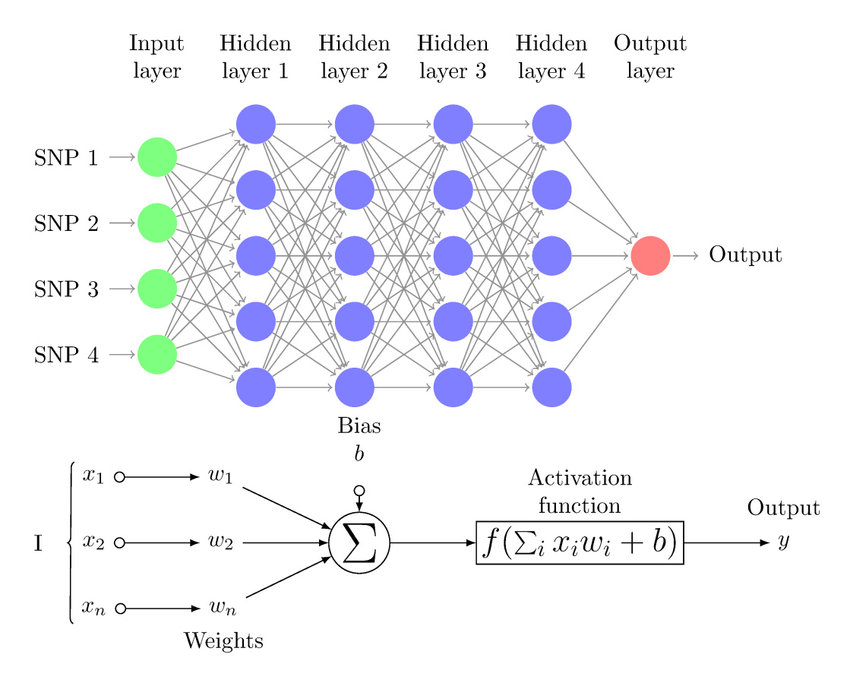

Post-process data after a layer. Applies non-linearity:

$$
y = \sigma(x)
$$

Common: ReLU, SiLU, sigmoid, tanh, softmax

$$
\text{ReLU}(x) = \max(0, x)
$$

### Why needed?

Without activation:
- $\text{network} = \text{linear function}$
⟶ Cannot model complex patterns


![](https://camo.githubusercontent.com/4647a8e926032a64a72acea7c2b48174e62563f3777e15fb2dbf7bf06699f385/68747470733a2f2f696d672e6966756e6e792e636f2f696d616765732f356635656566346537316632633731646332353030383738313639643534343530323539653434343637326530336666656237613466326536616130373261395f312e6a7067)

## Common Activation Functions

| Name | Formula | Characteristics | Common Use |
|------|--------|----------------|-----------|
| ReLU (Rectified Linear Unit) | $f(x) = \max(0, x)$ | Simple, fast, sparse activation (many zeros), may suffer from "dead neurons" | Default choice for hidden layers in CNNs |
| Leaky ReLU | $f(x) = \max(\alpha x, x)$ | Allows small gradient when $x < 0$, avoids dead neurons | Alternative to ReLU when dead neurons are a problem |
| Sigmoid | $f(x) = \frac{1}{1 + e^{-x}}$ | Output in $(0,1)$, smooth, suffers from vanishing gradients | Binary classification output layer |
| Tanh | $f(x) = \tanh(x)$ | Output in $(-1,1)$, zero-centered, still suffers from vanishing gradients | Hidden layers (older networks), sometimes better than sigmoid |
| Softmax | $f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$ | Outputs probability distribution (sum = 1) | Multi-class classification output layer |
| ELU (Exponential Linear Unit) | $f(x) = \begin{cases} x & x > 0 \\ \alpha(e^x - 1) & x \le 0 \end{cases}$ | Smooth, allows negative values, faster convergence than ReLU | Deep networks, alternative to ReLU |
| GELU (Gaussian Error Linear Unit) | $f(x) = x \cdot \Phi(x)$ | Smooth, probabilistic interpretation, strong performance | Modern architectures (e.g. Vision Transformers) |
| SiLU (Swish) | $f(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$ | Smooth, non-monotonic, better gradient flow than ReLU | Modern CNNs and models (e.g. EfficientNet, YOLO) |

---
# 10. Forward Pass (How prediction works)
---

![](https://miro.medium.com/v2/resize:fit:1280/1*Sub77mLgllQHpoDO_jh6BQ.gif)

## Process

$$
x \rightarrow \text{Conv} \rightarrow \text{Activation} \rightarrow \cdots \rightarrow y
$$

Each layer:

* transforms representation
* extracts more abstract features

## Intuition

| Layer       | Learns         |
| ----------- | -------------- |
| Conv 1      | edges          |
| Conv 2      | shapes         |
| Conv deeper | object parts   |
| FC          | class decision |

---
# 11. Backpropagation (How learning works)
---

![](https://miro.medium.com/0*d9yJ5xIqdbDyjCYR.gif)

Goal is to minimize error:

$$
L = ||y_{pred} - y_{true}||
$$

## 11.1 Key Idea

Error flows **backwards** through the network.

Each layer learns:

> “How much did I contribute to the error?”


## 11.2 Update Rule

$$
W := W - \eta \frac{\partial L}{\partial W}
$$

More details require a bunch of calculus (chain rules and that...)

## 11.3 Intuition

* good weights → reinforced
* bad weights → reduced

---
# 12. What Must Be Stored
---

During training:

* Forward pass stores activations of each layer
* Backward pass computes gradients (same size as activations)

⇒ Memory required:

$$
\text{activations} + \text{gradients} (+ \text{parameters})
$$

---

---
# 13. How to Design an Architecture
---

## Step 1: Match Output Sizes

$$
H_{out} = \frac{H - K + 2P}{S} + 1
$$

## Step 2: Reduce Resolution

Use either:
* stride > 1
* pooling

## Step 3: Adjust Channels

* use convolution
* Remember: number of filters = output channels

## Step 4: Go to decision

* flatten
* FC → number of classes

## Common Mistakes

* forgetting stride in size calculation
* mixing up channels vs spatial size
* forgetting flatten before FC
* wrong parameter count for conv (missing $C_{in}$)

---

# Summary

A CNN architecture is built from:

* Convolution → feature extraction
* Activation → non-linearity
* Pooling → downsampling
* Flatten → reshape
* FC → classification

Learning happens through:

* forward pass (compute output)
* backpropagation (update weights)

Each layer exists to:

* reduce spatial complexity
* increase feature abstraction
* enable final classification


---
# Exercises
---

Write down the calculations for the number of parameters of the following models:

## Model 1

```python
mlp = keras.Sequential(
    [
        layers.Input((28,28,1)),               # Tell Keras the shape of the input array (a single-channel 28×28 image)
        layers.Flatten(),                      # Unravel/flatten the input array
        layers.Dense(16, activation='relu'),   # Add a fully-connected layer with 16 units and ReLU activation function as the hidden layer
        layers.Dense(10, activation='softmax') # Add a fully-connected layer with a softmax activation function
    ]
)
```

```
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 16)                12560     
_________________________________________________________________
dense_1 (Dense)              (None, 10)                170       
=================================================================
Total params: 12,730
Trainable params: 12,730
Non-trainable params: 0
_________________________________________________________________

```
`dense`: $784\times16+16 = 12560$ (784 channels in, 16 channels out, plus bias).

`dense_1`: $16\times10+10 = 170$ (16 channels in, 10 channels out, plus bias).

**Total params**: $12560+170 = 12730$

*Remember: transformation layers (flatten, pooling, etc.) don't have parameters!*

## Model 2

```python
cnn = keras.Sequential(
    [
        layers.Input((28, 28, 1)),

        layers.Conv2D(8, (5, 5), activation='relu'), # fill in
        layers.MaxPooling2D((2, 2)), # fill in
        layers.Conv2D(16, (5, 5), activation='relu'), #fill in
        layers.MaxPooling2D((2, 2)), # fill in

        layers.Flatten(),
        layers.Dense(10, activation='softmax')
    ],
)
```

```
Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
conv2d (Conv2D)              (None, 24, 24, 8)         208       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 8)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 8, 8, 16)          3216      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 4, 4, 16)          0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 256)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                2570      
=================================================================
Total params: 5,994
Trainable params: 5,994
Non-trainable params: 0
_________________________________________________________________

```

* `conv2d`: $1 \times 8 \times 5 \times 5 +8$ (1 channels in, 8 channels out, $5 \times 5$ convolutional kernel).
* `conv2d_1`: $8 \times 16 \times 5 \times 5 + 16$ (8 channels in, 16 channels out, $5 \times 5$ convolutional kernel).
* `dense_2`: $256 \times 10 + 10$ (Flatten image and feed to fully connected layer w/ 10 output classes).
* Total params: $208+3216+2570 = 5994$

### UniMelb 2021 Exam

In the following CNN network, the input is a RGB image with values in the range 0-255. The convolution operation in the convolutional layers (A,B) are standard 2D convolution (i.e., each kernel has the same number of channels of the input, and the kernel goes through local patches of the input to conduct element-wise multiplication and then sum). Each convolutional layer uses a ReLU activation function. The final layer (D) is a fully connected layer with 10 units.

![CNN](https://raw.githubusercontent.com/saraao/COMP90086_image/main/cnn.png)

#### i) What is the total number of parameters in this network? Show your work.
Include bias, unless otherwise unspecified
- A : $5 * 5* 20 *3 + 20 = 1520$ parameters, output of size (22,22,20).
- B : $3*3 *20 * 40 + 40 = 7240$ parameters, output of size (20,20,40).
- C : Transformation layer ▶ 0 parameters,  output of size (10,10,40)
- D : $4000*10+10 = 40010$ parameters.

In total of $1520 + 7240 + 40010 = 48770$ parameters

#### ii) Suppose you initialise this network so that all parameters are equal to zero. If you run an image through this network, what will be the output of layer B? Give the dimensions of this output and a description of the values you would expect.

Answer: The output would be $20 \times 20 \times 40$, all zeros.

#### iii) Now suppose you initialise this network so that all weights are equal to 1 and all biases equal to 0. If you run an image through this network, what is the output of layer B? Describe what you would expect this layer's output to look like.

Answer: The output would be a stack of blurry versions of the input (both conv layers are initialised as averaging filters).

#### iv) How could you reduce the number of parameters in this network without reducing the number of filters or their effective kernel size?

Answer:
-	Replace the conv layers with separable convolution
-	Replace the $5 \times 5$ layer with stacked convolution